Import previous notebook to use its funcionts

In [1]:
import joblib as jl
import numpy as np 
import pandas as pd
#%run section_1_pre_processing.ipynb #  if i must use functions defined in first notebook
print("Libraries imported successfully.")

df = jl.load('df.pkl')

# Load the label names using joblib (jl) instead of pandas to avoid errors
list_label_names = jl.load('df_fingerprint_list.pkl')


Libraries imported successfully.


# **Section 2 – Supervised learning – classification**

Classify the tactics of an attack session, based on the used words in the text and also possibly on time.

Each session can have multiple labels. y are labels

In [2]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

# loading
# Parse Set_Fingerprint (stored as string representation of list)
loaded_fingerprints = jl.load("df_fingerprint_list.pkl")
ed_fingerprints = jl.load("df_fingerprint_list.pkl")

# CHECK DI SICUREZZA: Conversione da stringa a lista se necessario
if isinstance(loaded_fingerprints[0], str):
    print("ATT Rilevated strings! Conversion into list")
    # Esempio: converte "['tag1', 'tag2']" -> ['tag1', 'tag2']
    loaded_fingerprints = [ast.literal_eval(x) for x in loaded_fingerprints]
    
print(f"1. Data loaded. Type: {type(loaded_fingerprints)}")
print(f"2. Number of samples (rows): {len(loaded_fingerprints)}")

# Sanity check on the first element to ensure it's a list/iterable
if len(loaded_fingerprints) > 0:
    print(f"3. First element sample (raw): {loaded_fingerprints[0]}")
    print(f"   Type of first element: {type(loaded_fingerprints[0])}") 
    # ^ Important: Should be <class 'list'> or <class 'set'>, NOT <class 'str'>


# Create the binary matrix for multi-label classification
multi_label_binarizer = MultiLabelBinarizer()
y = multi_label_binarizer.fit_transform(loaded_fingerprints)

#to check output
print(f"4. Number of unique classes found: {len(multi_label_binarizer.classes_)}")
print(f"5. 7 classes (labels): {multi_label_binarizer.classes_}")
print(f"6. Final 'y' matrix shape: {y.shape}") 
# y.shape should be (n_samples, n_classes)

# Dump
jl.dump(y, 'matrice_y.pkl')
print("'matrice_y.pkl' saved successfully \n")


1. Data loaded. Type: <class 'pandas.core.series.Series'>
2. Number of samples (rows): 233035
3. First element sample (raw): ['Defense Evasion' 'Discovery']
   Type of first element: <class 'numpy.ndarray'>
4. Number of unique classes found: 7
5. 7 classes (labels): ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']
6. Final 'y' matrix shape: (233035, 7)
'matrice_y.pkl' saved successfully 



### 2.1 Split data set

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# load tfidf matrix used into first notebook
X_tfidf = jl.load('X_tfidf_matrix.pkl')
# load y
y = jl.load('matrice_y.pkl')

# PRE-SPLIT DIMENSION CHECK
print(f"1. Shape of X (TF-IDF): {X_tfidf.shape}")
print(f"2. Shape of y (Target): {y.shape}")

# CRITICAL CHECK: The number of rows (samples) must match
if X_tfidf.shape[0] != y.shape[0]:
    print(f"!!! CRITICAL WARNING: Row count mismatch! X has {X_tfidf.shape[0]} but y has {y.shape[0]}")
    print("!!! The split will likely fail or produce incorrect results.")
else:
    print("OK: Row counts align.")

#SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,   # 20% of data for test set
    random_state=42
)

# POST-SPLIT DIMENSION CHECK
print(f"3. Train Set -> X: {X_train.shape}, y: {y_train.shape}")
print(f"4. Test Set  -> X: {X_test.shape}, y: {y_test.shape}")

# Verify split ratio
print(f"Actual Test percentage: {X_test.shape[0] / X_tfidf.shape[0]:.2%}")
print("Split completed successfully")

1. Shape of X (TF-IDF): (233035, 1000)
2. Shape of y (Target): (233035, 7)
OK: Row counts align.
3. Train Set -> X: (186428, 1000), y: (186428, 7)
4. Test Set  -> X: (46607, 1000), y: (46607, 7)
Actual Test percentage: 20.00%
Split completed successfully


Use the following function to print the confusin matrix of the two model

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_mcm(mcm, class_names, title="Model"):
    """
    Stampa la Multilabel Confusion Matrix usando lo stile 'bello' con ConfusionMatrixDisplay.
    
    Args:
        mcm: La matrice di confusione multilabel (output di multilabel_confusion_matrix)
        class_names: Lista con i nomi delle classi
        title: Titolo generale per i plot
    """
    n_classes = len(class_names)
    cols = min(3, n_classes)
    rows = (n_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    # Gestione caso singola classe o più classi per appiattire axes
    axes = axes.flatten() if n_classes > 1 else [axes]

    for i, class_label in enumerate(class_names):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=mcm[i],
            display_labels=[f'Not {class_label}', class_label]
        )
        # Lo stile che ti piaceva: Blues, valori interi, niente colorbar singola
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f'Confusion Matrix: {class_label}', fontsize=10, fontweight='bold')

    # Nascondi assi vuoti se ci sono
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"{title} - Multilabel Confusion Matrices", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 2.2 Train 2 model

Initializes and trains a Random Forest Classifier, generating predictions and computing detailed performance metrics for both training and test sets. It displays the classification reports and visualizes the test set results using a custom confusion matrix plotting function.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# Model Creation and Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Compute Metrics
# Evaluation on TRAINING set
mcm_train_rf = multilabel_confusion_matrix(y_train, y_pred_train)
report_train_rf = classification_report(y_train, y_pred_train, zero_division=0)

# Evaluation on TEST set 
mcm_test_rf = multilabel_confusion_matrix(y_test, y_pred_test)
report_test_rf = classification_report(y_test, y_pred_test, zero_division=0)

# print
print("CLASSIFICATION REPORT (TRAIN)")
print(report_train_rf)
print("-" * 30)
print("CLASSIFICATION REPORT (TEST)")
print(report_test_rf)
print("-" * 30)

# Display confusion matrix
#NON CANCELLARE QUESTA RIGA: rf_class_names = [str(c) for c in rf_model.classes_] 
############# possibile SEZIONE PROBLEMATICA ################# 
#Extract the list of strings. This handles if the file contains a DataFrame or a List.
if hasattr(list_label_names, 'columns'):
    rf_class_names = list_label_names.columns.tolist()
else:
    rf_class_names = list(list_label_names)
###########fine possibile sezione problematica ##############
######SE NON FUNZIONA COSÌ, DECOMMENTA LA RIGA DA NON CANCELLARE E DOMMENTA LA SEZIONE PROBLEMATICA####
plot_mcm(mcm_test_rf, rf_class_names, title="Random Forest (Test)")

CLASSIFICATION REPORT (TRAIN)
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     15239
           1       1.00      1.00      1.00    185712
           2       1.00      0.99      0.99     74415
           3       0.92      0.19      0.31      1748
           4       1.00      1.00      1.00        25
           5       1.00      0.98      0.99       260
           6       1.00      1.00      1.00    169014

   micro avg       1.00      0.99      1.00    446413
   macro avg       0.99      0.88      0.90    446413
weighted avg       1.00      0.99      1.00    446413
 samples avg       1.00      1.00      1.00    446413

------------------------------
CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3760
           1       1.00      1.00      1.00     46433
           2       1.00      0.99      0.99     18512
           3       0.93      0.18      0.3

Train a Multi-Output Logistic Regression model for multi-label classification, calculating performance metrics for both training and test sets. It then displays the classification reports and visualizes the confusion matrices for each specific class using a custom plotting function.

CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     15239
           1       1.00      1.00      1.00    185712
           2       1.00      0.99      0.99     74415
           3       0.90      0.16      0.27      1748
           4       0.00      0.00      0.00        25
           5       1.00      0.94      0.97       260
           6       1.00      1.00      1.00    169014

   micro avg       1.00      0.99      1.00    446413
   macro avg       0.84      0.72      0.74    446413
weighted avg       1.00      0.99      0.99    446413
 samples avg       1.00      0.99      1.00    446413

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3760
           1       1.00      1.00      1.00     46433
           2       1.00      0.99      0.99     18512
           3       0.93      0.18      0.31       458
           4       0.00      0.00      0.00         2
 

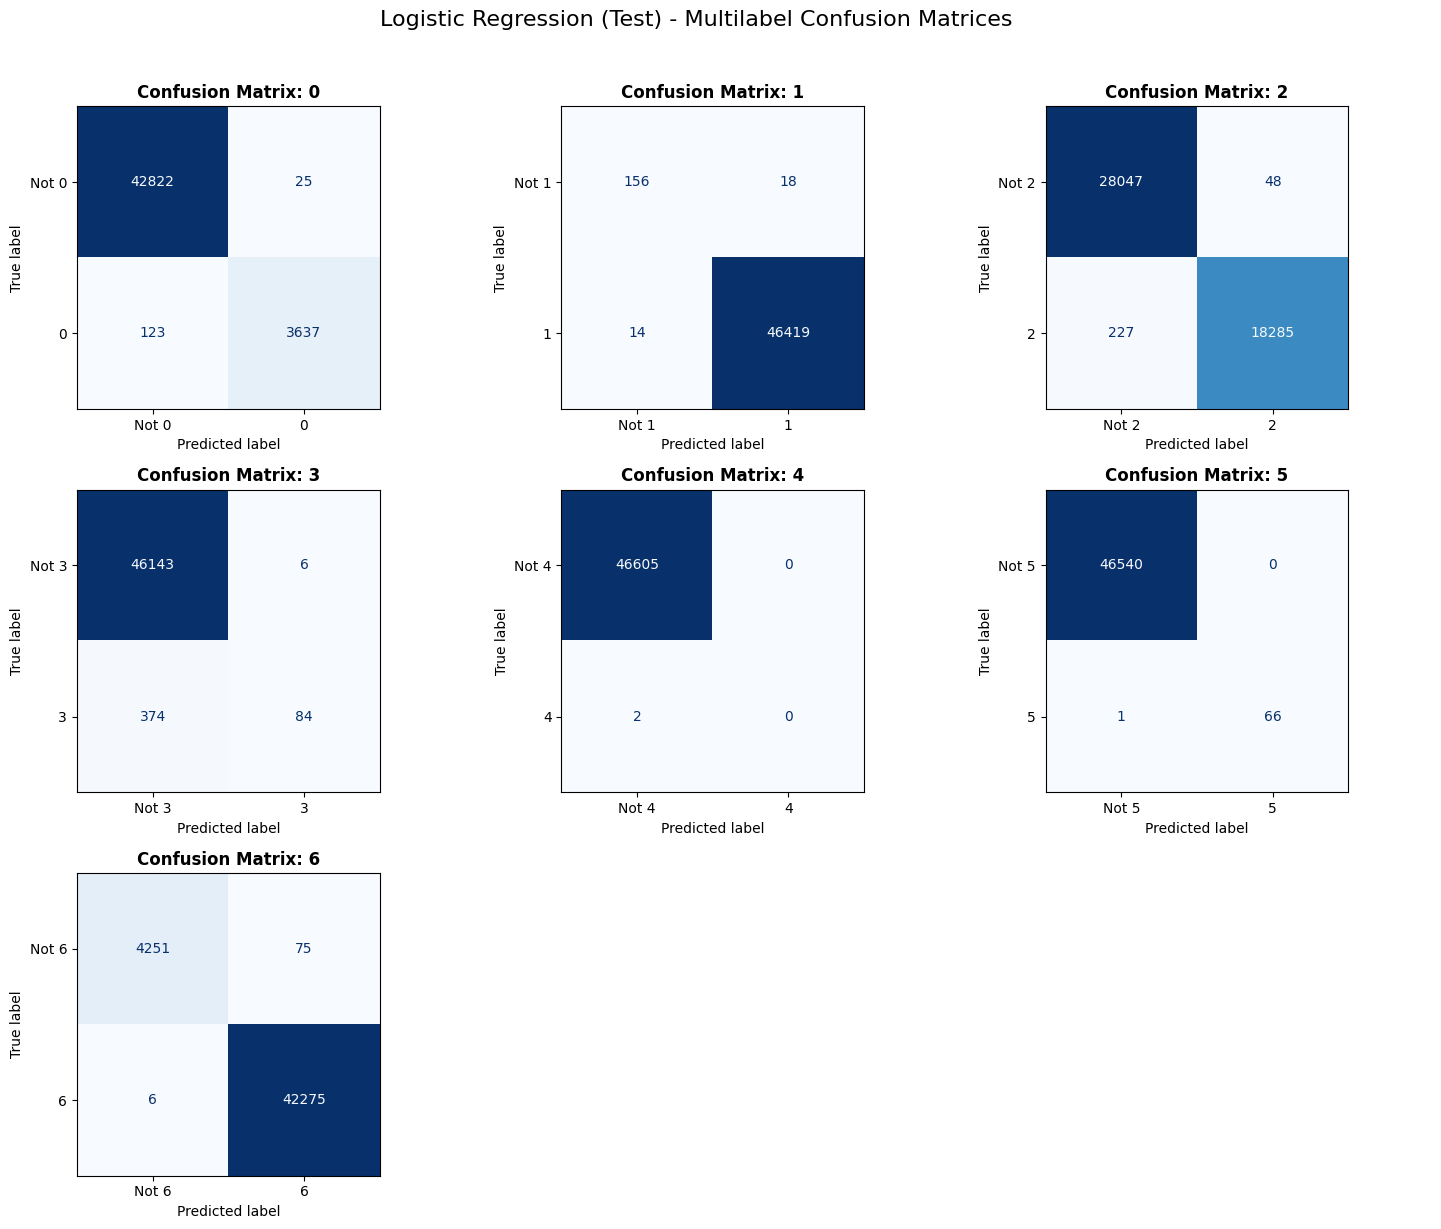

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# Use MultiOutputClassifier to handle multi-label
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

# Evaluation on TRAINING set
mcm_lr_train = multilabel_confusion_matrix(y_train, y_pred_lr_train) 
report_lr_train = classification_report(y_train, y_pred_lr_train, zero_division=0)


# Evaluation on TEST set
mcm_lr_test = multilabel_confusion_matrix(y_test, y_pred_lr_test) 
report_lr_test = classification_report(y_test, y_pred_lr_test, zero_division=0)

#print report
print("CLASSIFICATION REPORT ")
print(report_lr_train)
print(report_lr_test)


# VISUALIZE confusion matrices for each class 

# Display confusion matrix
#NON CANCELLARE QUESTA RIGA: lr_class_names = [str(c) for c in rf_model.classes_] 
############# possibile SEZIONE PROBLEMATICA ################# 
#Extract the list of strings. This handles if the file contains a DataFrame or a List.
if hasattr(list_label_names, 'columns'):
    lr_class_names = list_label_names.columns.tolist()
else:
    lr_model_class_names = list(list_label_names)
###########fine possibile sezione problematica ##############
###### SE NON FUNZIONA COSÌ, DECOMMENTA LA RIGA DA NON CANCELLARE E DOMMENTA LA SEZIONE PROBLEMATICA####
plot_mcm(mcm_lr_test, lr_class_names, title=" Logistic Regression (Test)")

Evaluate Random Forest and Logistic Regression models by analyzing F1-scores to detect overfitting or underfitting based on the generalization gap. It compares training and testing performance metrics for both classifiers and automatically identifies the best-performing model based on the test set results.

In [ ]:
print("\n" + "=" * 50)
print("OVERFITTING and UNDERFITTING ANALYSIS")
print("=" * 50)

# Extract F1-scores for comparison
def extract_f1(report_str):
    """Extract weighted avg f1-score from classification report string"""
    lines = report_str.split('\n')
    for line in lines:
        if 'weighted avg' in line:
            parts = line.split()
            return float(parts[-2])  # f1-score is second to last
    return 0.0

# Get f1-score from Random Forest and Logistic Regression
rf_train_f1 = extract_f1(report_train_rf)
rf_test_f1 = extract_f1(report_test_rf)
lr_train_f1 = extract_f1(report_lr_train)
lr_test_f1 = extract_f1(report_lr_test)

####################################
##### f1-score and check on rf #####
####################################
#print the f1 score of rf
print(f"\nRandom Forest:")
print(f"  Training F1: {rf_train_f1:.3f}")
print(f"  Test F1:     {rf_test_f1:.3f}")
print(f"  Gap:         {rf_train_f1 - rf_test_f1:.3f}")
#now do a check on over/under_fitting for rf
if rf_train_f1 - rf_test_f1 > 0.1:
    print("  OVERFITTING detected (large gap)")
elif rf_test_f1 < 0.6:
    print("   UNDERFITTING detected (low performance)")
else:
    print("  ✓ Good generalization")

####################################
##### f1-score and check on lr #####
####################################
#print the f1 score of lr
print(f"\nLogistic Regression:")
print(f"  Training F1: {lr_train_f1:.3f}")
print(f"  Test F1:     {lr_test_f1:.3f}")
print(f"  Gap:         {lr_train_f1 - lr_test_f1:.3f}")
#now do a check on over/under_fitting for lr
if lr_train_f1 - lr_test_f1 > 0.1:
    print("  OVERFITTING detected (large gap)")
elif lr_test_f1 < 0.6:
    print("  UNDERFITTING detected (low performance)")
else:
    print("  ✓ Good generalization")

#establish which model perform best
print("\n" + "=" * 50)
print("BEST MODEL")
print("=" * 50)
if rf_test_f1 > lr_test_f1:
    print(f" Random Forest performs best (Test F1: {rf_test_f1:.3f})")
else:
    print(f" Logistic Regression performs best (Test F1: {lr_test_f1:.3f})")




OVERFITTING and UNDERFITTING ANALYSIS

Random Forest:
  Training F1: 1.000
  Test F1:     1.000
  Gap:         0.000
  ✓ Good generalization

Logistic Regression:
  Training F1: 0.990
  Test F1:     0.990
  Gap:         0.000
  ✓ Good generalization

BEST MODEL
 Random Forest performs best (Test F1: 1.000)


### 2.3 Hyper-parameters tuning